In [1]:
import sys
sys.path.append('../scripts')
from scripts.preprocess import load_and_preprocess_data
from scripts.hyperparameter_tuning import tune_hyperparameters
from scripts.lowess_anomaly_detection import validate_before_and_after_weights, lowess_anomaly_detection
import matplotlib.pyplot as plt
import seaborn as sns

file_path = '../data/cars_data.csv'

In [2]:
X_train, X_test, y_train, y_test = load_and_preprocess_data(file_path)

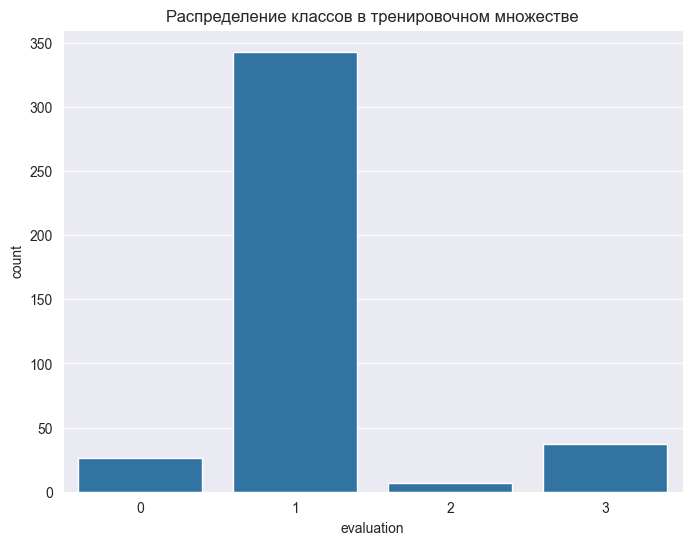

In [3]:
plt.figure(figsize=(8, 6))
sns.countplot(x=y_train)
plt.title('Распределение классов в тренировочном множестве')
plt.show()

In [4]:
best_params, best_score = tune_hyperparameters(X_train, y_train)
accuracy_before, accuracy_after = validate_before_and_after_weights(X_train, y_train, X_test, y_test, best_params)

Best Score: 0.8329121363502792
Best Parameters: window_type=radius, n_neighbors=None, radius=0.5, metric=chebyshev, kernel=uniform_kernel
[0.5        0.4        0.5        0.5        0.2        0.5
 0.5        0.5        0.3        0.4        0.10752688 0.4
 0.4        0.4        0.5        0.2        0.5        0.5
 0.5        0.1        0.4        0.39250544 0.5        0.47368421
 0.5        0.5        0.4        0.3        0.4        0.3
 0.2        0.47368421 0.5        0.5        0.4        0.47368421
 0.4        0.2        0.5        0.3        0.46808511 0.3
 0.43010753 0.5        0.2        0.5        0.46808511 0.4
 0.1        0.3        0.5        0.47368421 0.5        0.43010753
 0.5        0.3        0.4        0.21505376 0.47368421 0.47368421
 0.5        0.5        0.10752688 0.2        0.47222222 0.5
 0.32258065 0.47368421 0.47368421 0.47368421 0.5        0.4
 0.10526316 0.4        0.47368421 0.5        0.5        0.5
 0.5        0.5        0.40229885 0.47368421 0.4444444

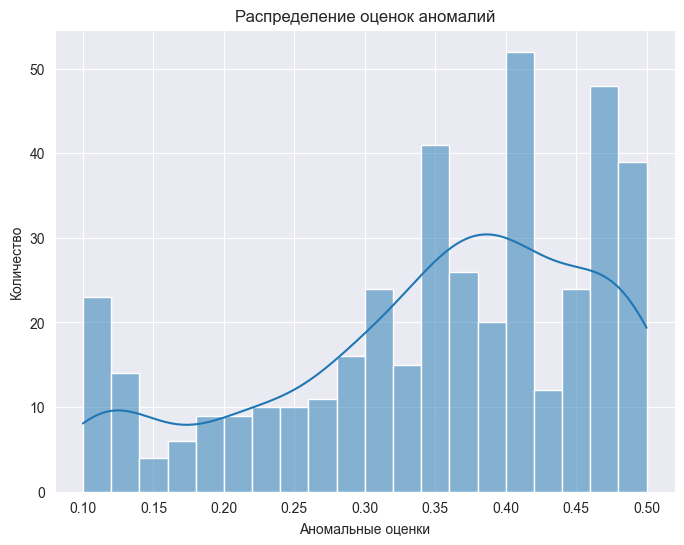

In [6]:
from scripts.knn_model import custom_kernel

anomaly_scores = lowess_anomaly_detection(X_train, y_train, custom_kernel, "minkowski")

plt.figure(figsize=(8, 6))
sns.histplot(anomaly_scores, bins=20, kde=True)
plt.title('Распределение оценок аномалий')
plt.xlabel('Аномальные оценки')
plt.ylabel('Количество')
plt.show()